In [1]:
!pip install kaggle -q

In [4]:
import os
from pathlib import Path
from getpass import getpass

# Paste your NEW token when asked. It will stay hidden.
token = getpass("Paste your NEW Kaggle API token here: ").strip()

# Basic validation
if not token:
    raise ValueError("Token is empty. Please paste your Kaggle API token.")

if not token.startswith("KGAT_"):
    print("Warning: New Kaggle API tokens usually start with KGAT_. Please check your token.")

# Set environment variable for current Colab session
os.environ["KAGGLE_API_TOKEN"] = token

# Save token where Kaggle CLI can automatically read it
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)

token_file = kaggle_dir / "access_token"
token_file.write_text(token)

# Secure permissions
os.chmod(kaggle_dir, 0o700)
os.chmod(token_file, 0o600)

print("Kaggle API token saved successfully.")
print("Token location:", token_file)

Paste your NEW Kaggle API token here: ··········
Kaggle API token saved successfully.
Token location: /root/.kaggle/access_token


In [5]:
!kaggle competitions list


ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [6]:
!kaggle datasets list -s iris

ref                                                     title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
uciml/iris                                              Iris Species                                         3687  2016-09-27 07:38:05.440000         893197       4822  0.7941176        
himanshunakrani/iris-dataset                            Iris dataset                                         1006  2022-07-20 18:50:06.277000         103602        407  1                
arshid/iris-flower-dataset                              Iris Flower Dataset                                  1010  2018-03-22 15:18:06.097000         250505       1123  0.8235294        
vikrishnan/iris-dataset                                 Iris Data

In [7]:
!python -m pip install --upgrade kaggle -q
!kaggle --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 9.8 MB/s eta 0:00:00
Kaggle CLI 2.2.3


In [8]:
!mkdir -p data
!kaggle datasets download -d uciml/iris -p data --unzip
!ls data

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
100% 3.60k/3.60k [00:00<00:00, 6.95MB/s]

database.sqlite  Iris.csv


In [9]:
import pandas as pd

df = pd.read_csv("/content/data/Iris.csv")

display(df.head())
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nClass Distribution:")
print(df["Species"].value_counts())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Dataset Shape: (150, 6)

Columns:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

# Remove Id column because it is not useful for prediction
df = df.drop("Id", axis=1)

X = df.drop("Species", axis=1)
y = df["Species"]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Input Features:")
print(X.head())

print("\nTarget Classes:")
print(encoder.classes_)

Input Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [13]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.9333333333333333
F1 Score: 0.9326599326599326

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


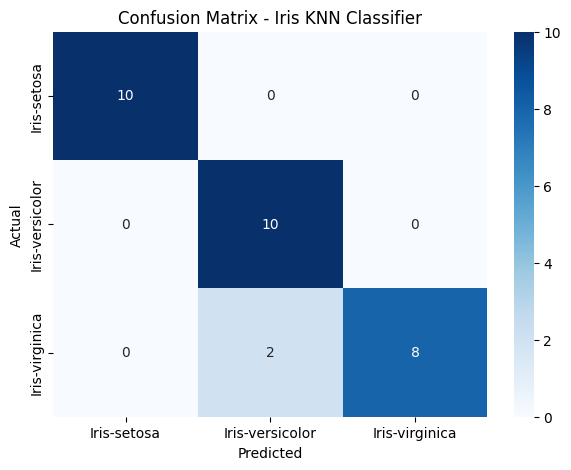

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris KNN Classifier")
plt.show()

In [16]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = scaler.transform(new_flower)
prediction = model.predict(new_flower_scaled)
predicted_species = encoder.inverse_transform(prediction)

print("Predicted Flower Species:", predicted_species[0])

Predicted Flower Species: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
import joblib

joblib.dump(model, "iris_knn_model.pkl")
joblib.dump(scaler, "iris_scaler.pkl")
joblib.dump(encoder, "iris_label_encoder.pkl")

print("Model files saved successfully.")

Model files saved successfully.


In [18]:
from google.colab import files

files.download("iris_knn_model.pkl")
files.download("iris_scaler.pkl")
files.download("iris_label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>